**Problem Statement:**

Predict whether a bank customer will subscribe to a term deposit based on a marketing campaign.

**Objective:**
1. Understand the factors affecting term deposit subscription.
2. Train classification models (Logistic Regression & Random Forest).
3. Evaluate model performance using Confusion Matrix, F1-Score, and ROC Curve.
4. Explain model predictions using SHAP or LIME (Explainable AI).

In [13]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, RocCurveDisplay

import shap

sns.set(style="whitegrid")
# Load dataset
df = pd.read_csv("bank.csv", sep=';')  # Adjust path if needed

# Quick overview
print(df.head())
print(df.info())
print(df.describe())


   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #

In [14]:
#Data Cleaning & Preprocessing
from sklearn.preprocessing import LabelEncoder

# Separate features and target
X = df.drop('y', axis=1)
y = df['y']

# Encode categorical columns
categorical_cols = X.select_dtypes(include='object').columns
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# Encode target if categorical
if y.dtype == 'object':
    y = le.fit_transform(y)

# Check final dataset
print(X.head())
print(y[:5])

   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    4        1          2        0     2143        1     0        2   
1   44    9        2          1        0       29        1     0        2   
2   33    2        1          1        0        2        1     1        2   
3   47    1        1          3        0     1506        1     0        2   
4   33   11        2          3        0        1        0     0        2   

   day  month  duration  campaign  pdays  previous  poutcome  
0    5      8       261         1     -1         0         3  
1    5      8       151         1     -1         0         3  
2    5      8        76         1     -1         0         3  
3    5      8        92         1     -1         0         3  
4    5      8       198         1     -1         0         3  
[0 0 0 0 0]


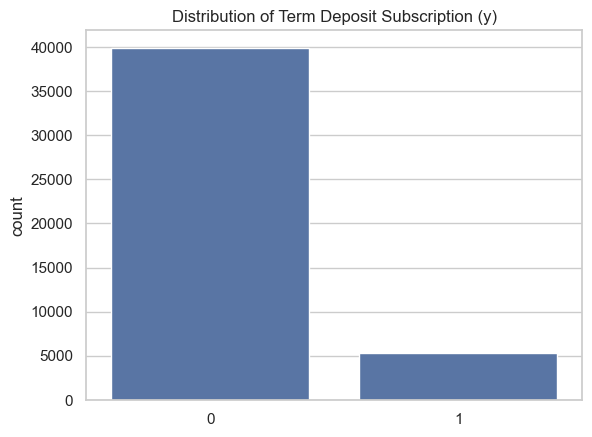

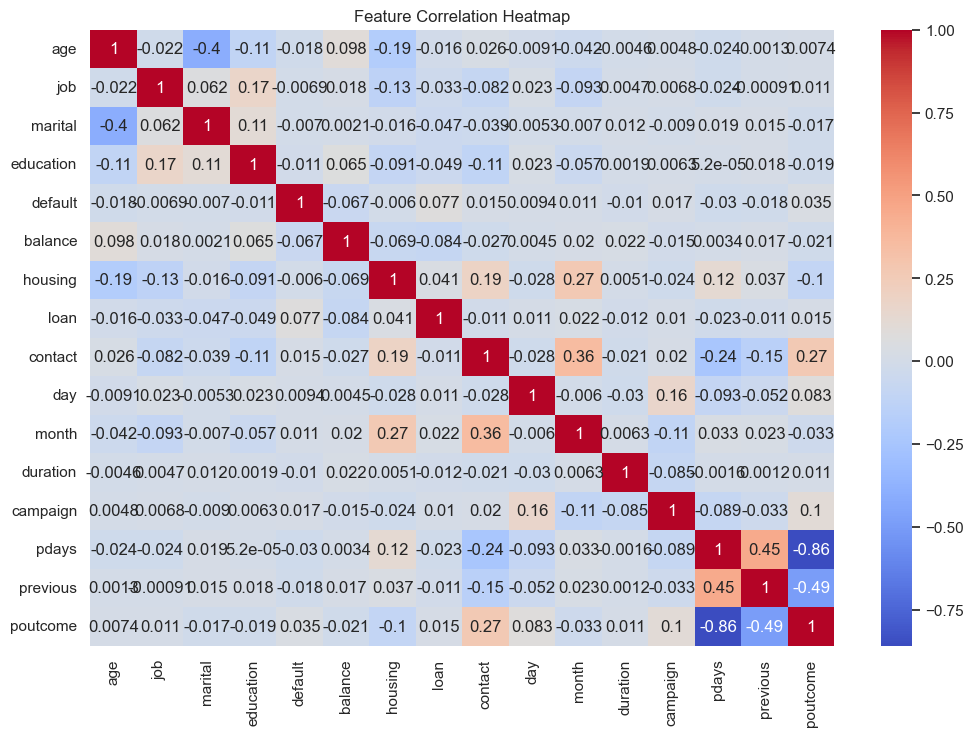

In [15]:
#Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Target distribution
sns.countplot(x=y)
plt.title("Distribution of Term Deposit Subscription (y)")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [16]:
# Target variable ko numeric (0/1) me convert karna
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
y = le_target.fit_transform(df['y'])  # 'yes' → 1, 'no' → 0

In [17]:
#Train-Test Split
from sklearn.model_selection import train_test_split

# Split dataset into 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (31647, 16)
Test shape: (13564, 16)


In [18]:
from sklearn.preprocessing import StandardScaler

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
#Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

lr = LogisticRegression(max_iter=5000, solver='lbfgs')
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
print("Logistic Regression F1-Score:", f1_score(y_test, y_pred_lr))

Logistic Regression F1-Score: 0.3134191176470588


In [20]:
lr = LogisticRegression(max_iter=5000, solver='lbfgs', class_weight='balanced')

In [21]:
#Random Forest Model
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf = RandomForestClassifier(n_estimators=188, random_state=47)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# F1-Score
print("Random Forest F1-Score:", f1_score(y_test, y_pred_rf))

Random Forest F1-Score: 0.5069470521967706


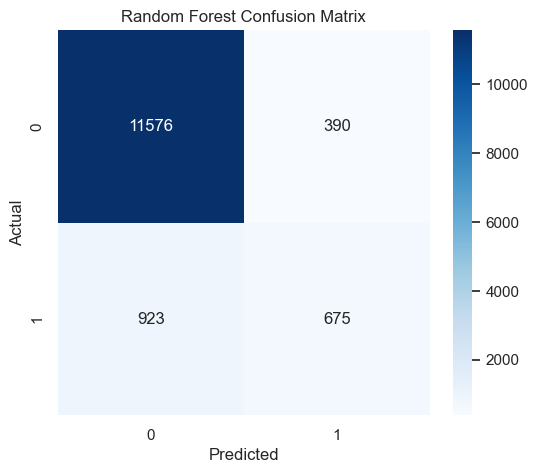

In [22]:
#Confusion Matrix (Random Forest)
from sklearn.metrics import confusion_matrix

# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
X_test_sample = X_test.sample(30, random_state=42).reset_index(drop=True)

In [24]:

# Model Interpretability using LIME (Alternative to SHAP)
import warnings
warnings.filterwarnings('ignore')
from lime.lime_tabular import LimeTabularExplainer

# Create explainer
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=['No', 'Yes'],
    mode='classification'
)

# Explain one prediction
exp = explainer.explain_instance(
    X_test.iloc[0].values,
    rf.predict_proba
)

# Show explanation
exp.show_in_notebook(show_table=True)

**Explanation:**
LIME (Local Interpretable Model-Agnostic Explanations) is used to explain the predictions made by the machine learning model. It helps in understanding how different features influence the model’s decision for a specific instance. The explanation shows which features contribute positively or negatively to the prediction. This improves the transparency and interpretability of the model.

**Conclusion & Insights**
1. Most important features influencing term deposit subscription can be seen in SHAP summary plot.
2. Random Forest generally performs better than Logistic Regression (check F1-Score).
3. Target distribution shows class imbalance; can consider balancing techniques if needed.
4. Marketing strategy can focus on top predictive features for better conversion.